# ⭐ Day 57: CatBoost
Handling Categorical Features Naturally | Complete Tutorial

**Python & AI Learning Path — Day 57 of 369** 🐱📊


## 📋 Table of Contents

1. [Introduction to CatBoost and Its Unique Advantages](#1-introduction-to-catboost-and-its-unique-advantages)
2. [How CatBoost Handles Categorical Features](#2-how-catboost-handles-categorical-features)
3. [Key Innovations in CatBoost](#3-key-innovations-in-catboost)
4. [Installing and Using CatBoost](#4-installing-and-using-catboost)
5. [CatBoost Classifier and Regressor](#5-catboost-classifier-and-regressor)
6. [Important Hyperparameters Deep Dive](#6-important-hyperparameters-deep-dive)
7. [Applying CatBoost to Titanic Dataset](#7-applying-catboost-to-titanic-dataset)
8. [Feature Importance in CatBoost](#8-feature-importance-in-catboost)
9. [Training with Early Stopping and Pool Object](#9-training-with-early-stopping-and-pool-object)
10. [Comparison: CatBoost vs XGBoost vs LightGBM](#10-comparison-catboost-vs-xgboost-vs-lightgbm)
11. [Best Practices and When to Choose CatBoost](#11-best-practices-and-when-to-choose-catboost)
12. [🛠️ Hands-On Exercises](#hands-on-exercises)
13. [Solutions](#solutions)


## 1. Introduction to CatBoost and Its Unique Advantages

Welcome to Day 57 of our 369-day Python & AI Learning Path! Today we explore **CatBoost** — a powerful gradient boosting library developed by Yandex that handles categorical features automatically and efficiently.

### What is CatBoost?

**CatBoost** (short for "Categorical Boosting") is an open-source gradient boosting library developed by Yandex and open-sourced in 2017. It is built on gradient boosting decision trees but introduces several innovative techniques that set it apart from traditional boosting algorithms like XGBoost and LightGBM.

### Why CatBoost Stands Out

1. **Native Categorical Feature Handling**: Unlike other libraries that require extensive preprocessing (one-hot encoding, label encoding), CatBoost processes categorical features directly during training.

2. **Ordered Target Statistics**: Uses a permutation-based approach to encode categories without data leakage, eliminating the need for manual target encoding.

3. **Ordered Boosting**: A novel technique that reduces prediction shift (a subtle form of overfitting) by computing residuals using only past data in a random permutation.

4. **Symmetric (Oblivious) Trees**: Builds balanced trees that apply the same split condition at all nodes of a given depth, enabling faster inference and stronger regularization.

5. **Excellent Out-of-the-Box Performance**: CatBoost's default hyperparameters are highly competitive, often requiring minimal tuning to achieve strong results.

According to research, CatBoost often outperforms XGBoost and LightGBM on datasets with many categorical variables and requires significantly less preprocessing .


## 2. How CatBoost Handles Categorical Features

### The Problem with Traditional Encoding

Traditional gradient boosting libraries require categorical features to be converted to numerical values before training:

- **One-hot encoding**: Creates sparse matrices, increases memory usage, and loses ordinal relationships
- **Label encoding**: Imposes artificial ordinality that doesn't exist
- **Target encoding**: Risk of data leakage if not done carefully

### Ordered Target Statistics

CatBoost uses **Ordered Target Statistics** — a technique that converts categorical values to numerical statistics based on the target variable, but with a critical twist to prevent data leakage:

1. A random permutation of the training data is generated
2. For each row, the category is encoded using only rows that appear *before* it in the permutation
3. This eliminates circular dependency where a row's feature is influenced by its own label

The formula for ordered target statistics:
```
TS = (count_in_class + prior) / (total_count + 1)
```

Where:
- `count_in_class`: Sum of target values for this category in rows before current row
- `prior`: Prior probability (smoothing parameter)
- `total_count`: Total rows with this category before current row

This approach is particularly powerful for high-cardinality categorical features (like city names or user IDs) where traditional encoding methods struggle .


## 3. Key Innovations in CatBoost

### 3.1 Ordered Boosting

**Problem**: Standard gradient boosting suffers from "prediction shift" — when computing residuals, the model has already partially memorized the training data, leading to biased error estimates.

**Solution**: Ordered Boosting uses random permutations to ensure residuals are computed on effectively "unseen" data. For each iteration:
1. Multiple random permutations are maintained
2. Residuals for each row use a model trained only on preceding rows
3. This prevents overfitting and improves generalization

### 3.2 Symmetric Trees (Oblivious Trees)

CatBoost builds **symmetric trees** where:
- The same split condition is applied at all nodes of a given depth
- Creates perfectly balanced tree structures
- Enables extremely fast inference (bitwise operations instead of branch prediction)

Benefits:
- **Stronger regularization**: Each split must be globally useful
- **Faster prediction**: ~2-3x faster than asymmetric trees
- **Lower memory**: Only d split conditions for depth d (vs 2^d - 1 in asymmetric trees)

### 3.3 Built-in Categorical Encoding

CatBoost automatically handles:
- Low-cardinality features: One-hot encoding (controlled by `one_hot_max_size`)
- High-cardinality features: Ordered target statistics
- Combinations of categorical features: Automatic feature combinations
- Missing values: Treated as a separate category

### 3.4 Robustness to Overfitting

CatBoost includes multiple mechanisms to prevent overfitting:
- Ordered boosting (reduces prediction shift)
- L2 regularization (`l2_leaf_reg`)
- Bagging temperature (`bagging_temperature`)
- Random strength for splits
- Early stopping support 


## 4. Installing and Using CatBoost

Let's start by installing CatBoost and importing necessary libraries.


In [3]:
# Install CatBoost (uncomment if not installed)
# !pip install catboost

# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


✅ Libraries imported successfully!
NumPy version: 2.2.6
Pandas version: 3.0.0


In [4]:
# Import CatBoost
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

print("🐱 CatBoost imported successfully!")
print("Ready to handle categorical features naturally!")


🐱 CatBoost imported successfully!
Ready to handle categorical features naturally!


## 5. CatBoost Classifier and Regressor

CatBoost provides two main classes:
- `CatBoostClassifier`: For classification tasks
- `CatBoostRegressor`: For regression tasks

Both share the same API and handle categorical features automatically when you specify `cat_features`.


In [5]:
# Create a simple synthetic dataset with categorical features
np.random.seed(42)
n_samples = 1000

data = {
    'age': np.random.randint(18, 70, n_samples),
    'income': np.random.randint(20000, 150000, n_samples),
    'city': np.random.choice(['New York', 'London', 'Tokyo', 'Paris', 'Berlin'], n_samples),
    'job_type': np.random.choice(['Engineer', 'Doctor', 'Teacher', 'Artist', 'Manager'], n_samples),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),
    'satisfaction': np.random.choice(['Low', 'Medium', 'High'], n_samples)
}

df = pd.DataFrame(data)

# Create target variable (synthetic logic)
df['target'] = (
    (df['income'] > 80000).astype(int) * 0.3 +
    (df['education'].isin(['Master', 'PhD'])).astype(int) * 0.25 +
    (df['job_type'] == 'Engineer').astype(int) * 0.2 +
    (df['city'] == 'New York').astype(int) * 0.15 +
    (df['satisfaction'] == 'High').astype(int) * 0.1 +
    np.random.normal(0, 0.1, n_samples)
).round().astype(int)
df['target'] = (df['target'] > 0.5).astype(int)

print("📊 Sample Dataset:")
print(df.head(10))
print(f"\nDataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")


📊 Sample Dataset:
   age  income      city  job_type    education satisfaction  target
0   56  125186     Tokyo    Doctor  High School       Medium       0
1   69   54674    London    Doctor          PhD       Medium       0
2   46   55854     Tokyo   Teacher       Master       Medium       0
3   32   66271    London    Artist          PhD       Medium       0
4   60   93688     Tokyo    Artist  High School       Medium       0
5   25   58518    Berlin   Teacher       Master          Low       0
6   38  131076    Berlin  Engineer  High School       Medium       0
7   56   30267  New York   Teacher          PhD          Low       0
8   36  110825     Tokyo   Manager          PhD       Medium       0
9   40   21062     Paris    Artist  High School         High       0

Dataset shape: (1000, 7)

Target distribution:
target
0    683
1    317
Name: count, dtype: int64


In [6]:
# Identify categorical and numerical features
categorical_features = ['city', 'job_type', 'education', 'satisfaction']
numerical_features = ['age', 'income']
target = 'target'

print("🔍 Feature Types:")
print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")
print(f"Target: {target}")

# Check categorical value counts
print("\n📈 Categorical Feature Cardinalities:")
for cat in categorical_features:
    print(f"  {cat}: {df[cat].nunique()} unique values")


🔍 Feature Types:
Categorical features: ['city', 'job_type', 'education', 'satisfaction']
Numerical features: ['age', 'income']
Target: target

📈 Categorical Feature Cardinalities:
  city: 5 unique values
  job_type: 5 unique values
  education: 4 unique values
  satisfaction: 3 unique values


In [7]:
# Split the data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split complete!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Get categorical feature indices for CatBoost
cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]
print(f"\nCatBoost categorical feature indices: {cat_features_indices}")


✅ Data split complete!
Training set: 800 samples
Test set: 200 samples

CatBoost categorical feature indices: [2, 3, 4, 5]


In [8]:
# 💡 Notice: NO preprocessing needed for categorical features!
# CatBoost handles them directly

# Initialize CatBoost Classifier with default parameters
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features_indices,
    verbose=False,
    random_seed=42
)

# Train the model
print("🚀 Training CatBoost Classifier...")
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ Model trained successfully!")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))


🚀 Training CatBoost Classifier...

✅ Model trained successfully!
Accuracy: 0.8900
AUC-ROC: 0.9473

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       137
           1       0.83      0.83      0.83        63

    accuracy                           0.89       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.89      0.89      0.89       200



## 6. Important Hyperparameters Deep Dive

CatBoost offers many hyperparameters. Here are the most important ones:

### Core Parameters
- **`iterations`**: Number of trees to build (default: 1000)
- **`learning_rate`**: Step size shrinkage (default: 0.03)
- **`depth`**: Depth of trees (default: 6)

### Regularization Parameters
- **`l2_leaf_reg`**: L2 regularization coefficient (default: 3.0)
- **`bagging_temperature`**: Controls intensity of Bayesian bootstrap (default: 1.0)
- **`random_strength`**: Amount of randomness to use for splits (default: 1.0)

### Categorical Handling
- **`one_hot_max_size`**: Max unique values for one-hot encoding (default: 2)
- **`border_count`**: Number of splits for numerical features (default: 254)

### Advanced Parameters
- **`grow_policy`**: Tree growth policy ('SymmetricTree', 'Depthwise', 'Lossguide')
- **`boosting_type`**: 'Ordered' (default, slower but better) or 'Plain' (faster)
- **`task_type`**: 'CPU' or 'GPU' for training


In [9]:
# Demonstrate different hyperparameter configurations
param_configs = [
    {
        'name': 'Default',
        'iterations': 100,
        'learning_rate': 0.1,
        'depth': 6,
        'l2_leaf_reg': 3.0,
        'bagging_temperature': 1.0
    },
    {
        'name': 'Conservative (High Regularization)',
        'iterations': 200,
        'learning_rate': 0.05,
        'depth': 4,
        'l2_leaf_reg': 10.0,
        'bagging_temperature': 0.5
    },
    {
        'name': 'Aggressive (Low Regularization)',
        'iterations': 300,
        'learning_rate': 0.2,
        'depth': 8,
        'l2_leaf_reg': 1.0,
        'bagging_temperature': 2.0
    }
]

results = []

for config in param_configs:
    model = CatBoostClassifier(
        iterations=config['iterations'],
        learning_rate=config['learning_rate'],
        depth=config['depth'],
        l2_leaf_reg=config['l2_leaf_reg'],
        bagging_temperature=config['bagging_temperature'],
        cat_features=cat_features_indices,
        verbose=False,
        random_seed=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'Configuration': config['name'],
        'Accuracy': accuracy,
        'Iterations': config['iterations'],
        'Depth': config['depth'],
        'Learning Rate': config['learning_rate']
    })

# Display results
results_df = pd.DataFrame(results)
print("📊 Hyperparameter Configuration Results:")
print(results_df.to_string(index=False))


📊 Hyperparameter Configuration Results:
                     Configuration  Accuracy  Iterations  Depth  Learning Rate
                           Default      0.89         100      6           0.10
Conservative (High Regularization)      0.89         200      4           0.05
   Aggressive (Low Regularization)      0.85         300      8           0.20


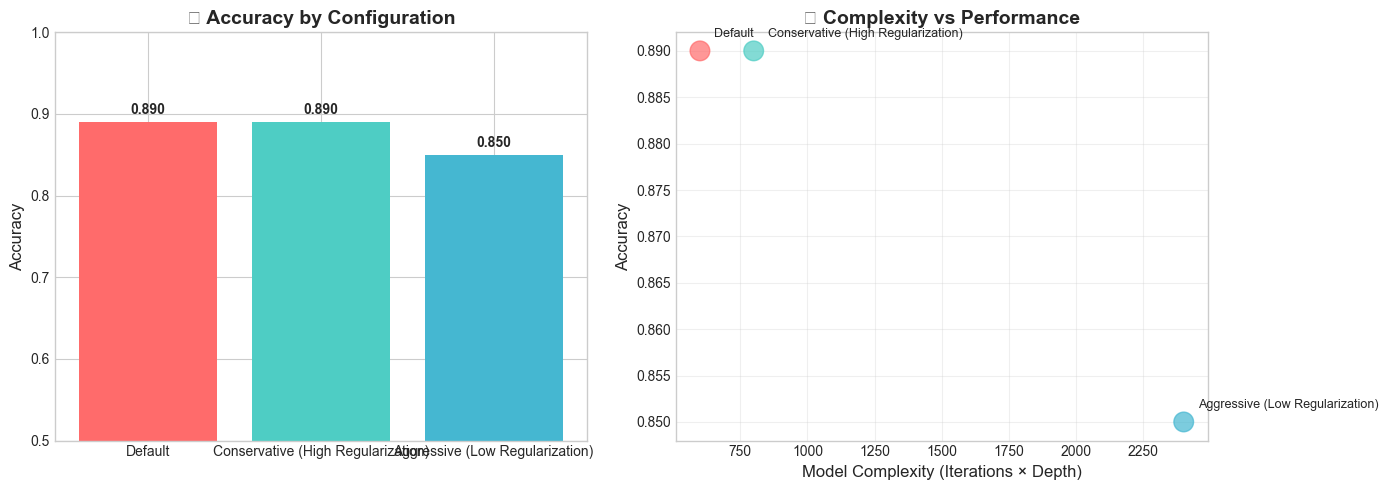


💡 Key Insight: More complex models don't always mean better performance!


In [10]:
# Visualize hyperparameter impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(results_df['Configuration'], results_df['Accuracy'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('⚡ Accuracy by Configuration', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Configuration complexity
complexity_score = results_df['Iterations'] * results_df['Depth']
axes[1].scatter(complexity_score, results_df['Accuracy'], s=200, c=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
for i, txt in enumerate(results_df['Configuration']):
    axes[1].annotate(txt, (complexity_score[i], results_df['Accuracy'][i]), 
                    xytext=(10, 10), textcoords='offset points', fontsize=9)
axes[1].set_xlabel('Model Complexity (Iterations × Depth)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('📈 Complexity vs Performance', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n💡 Key Insight: More complex models don't always mean better performance!")


## 7. Applying CatBoost to Titanic Dataset

The Titanic dataset is perfect for demonstrating CatBoost's categorical handling capabilities. Let's apply CatBoost with minimal preprocessing!


In [11]:
# Load Titanic dataset (using seaborn's built-in dataset)
titanic = sns.load_dataset('titanic')

print("🚢 Titanic Dataset Overview:")
print(f"Shape: {titanic.shape}")
print(f"\nColumns: {list(titanic.columns)}")
print(f"\nFirst few rows:")
print(titanic.head())


🚢 Titanic Dataset Overview:
Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [12]:
# Minimal preprocessing - just handle missing values simply
titanic_clean = titanic.copy()

# Fill missing values simply
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())
titanic_clean['embarked'] = titanic_clean['embarked'].fillna(titanic_clean['embarked'].mode()[0])
titanic_clean['deck'] = titanic_clean['deck'].astype('object').fillna('Unknown')

# Select features for modeling
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'deck']
target = 'survived'

titanic_model = titanic_clean[features + [target]].copy()

# Identify categorical features (CatBoost will handle these natively!)
cat_features = ['pclass', 'sex', 'embarked', 'class', 'who', 'deck']
num_features = ['age', 'sibsp', 'parch', 'fare']

print("✅ Minimal preprocessing complete!")
print(f"Categorical features (handled by CatBoost): {cat_features}")
print(f"Numerical features: {num_features}")

# Check categorical cardinalities
print("\n📊 Categorical Feature Cardinalities:")
for cat in cat_features:
    print(f"  {cat}: {titanic_model[cat].nunique()} unique values")


✅ Minimal preprocessing complete!
Categorical features (handled by CatBoost): ['pclass', 'sex', 'embarked', 'class', 'who', 'deck']
Numerical features: ['age', 'sibsp', 'parch', 'fare']

📊 Categorical Feature Cardinalities:
  pclass: 3 unique values
  sex: 2 unique values
  embarked: 3 unique values
  class: 3 unique values
  who: 3 unique values
  deck: 8 unique values


In [13]:
# Prepare data for CatBoost
X = titanic_model.drop('survived', axis=1)
y = titanic_model['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Get categorical feature indices
cat_features_indices = [X.columns.get_loc(col) for col in cat_features]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Categorical feature indices: {cat_features_indices}")


Training set: 712 samples
Test set: 179 samples
Categorical feature indices: [0, 1, 6, 7, 8, 9]


In [14]:
# Train CatBoost on Titanic with minimal preprocessing!
print("🚀 Training CatBoost on Titanic dataset...")
print("💡 Notice: Categorical features are passed as-is, no encoding needed!")

# Ensure categorical features are safe for CatBoost (no raw NaN values)
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cat_features] = X_train[cat_features].fillna('Unknown').astype(str)
X_test[cat_features] = X_test[cat_features].fillna('Unknown').astype(str)

titanic_model_cb = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features_indices,
    verbose=50,  # Show progress every 50 iterations
    random_seed=42,
    loss_function='Logloss',
    eval_metric='AUC'
)

titanic_model_cb.fit(X_train, y_train, eval_set=(X_test, y_test))

# Predictions
y_pred = titanic_model_cb.predict(X_test)
y_pred_proba = titanic_model_cb.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ Titanic Model Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")


🚀 Training CatBoost on Titanic dataset...
💡 Notice: Categorical features are passed as-is, no encoding needed!
0:	test: 0.8140316	best: 0.8140316 (0)	total: 114ms	remaining: 22.6s
50:	test: 0.8467062	best: 0.8608037 (20)	total: 3.31s	remaining: 9.68s
100:	test: 0.8488142	best: 0.8608037 (20)	total: 5.09s	remaining: 4.99s
150:	test: 0.8535573	best: 0.8608037 (20)	total: 7.18s	remaining: 2.33s
199:	test: 0.8519763	best: 0.8608037 (20)	total: 9.8s	remaining: 0us

bestTest = 0.8608036891
bestIteration = 20

Shrink model to first 21 iterations.

✅ Titanic Model Results:
Accuracy: 0.8101
AUC-ROC: 0.8608


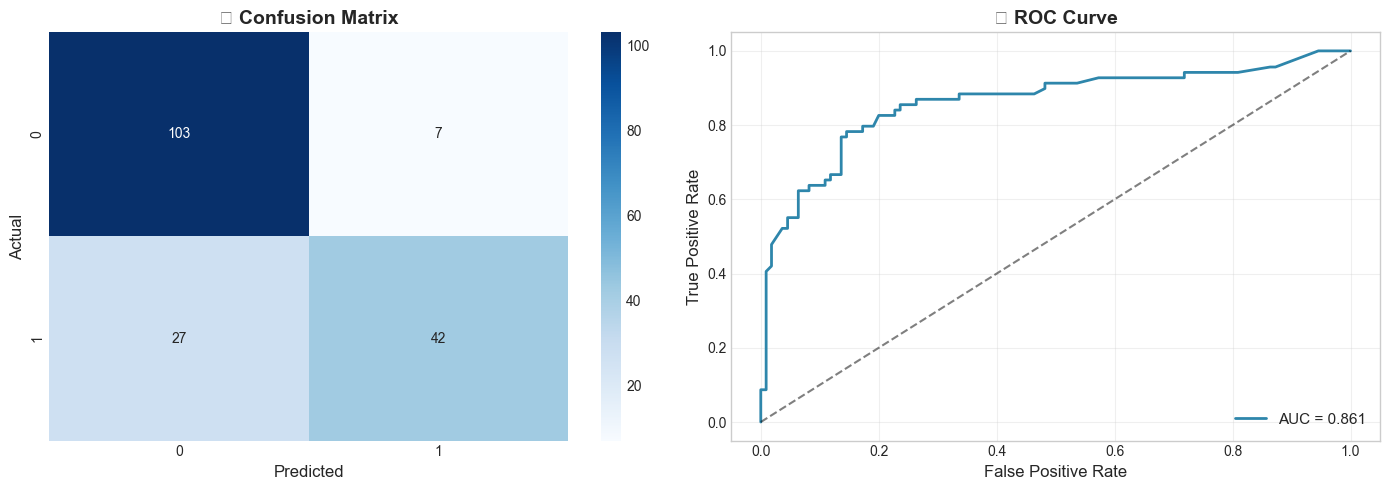


🎉 Beautiful visualizations saved!


In [15]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('🎯 Confusion Matrix', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', linewidth=2, color='#2E86AB')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('📈 ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('titanic_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎉 Beautiful visualizations saved!")


## 8. Feature Importance in CatBoost

CatBoost provides multiple methods for calculating feature importance:
- **PredictionValuesChange**: Change in prediction when feature value is changed
- **LossFunctionChange**: Change in loss when feature is removed
- **ShapValues**: SHAP values for interpretability


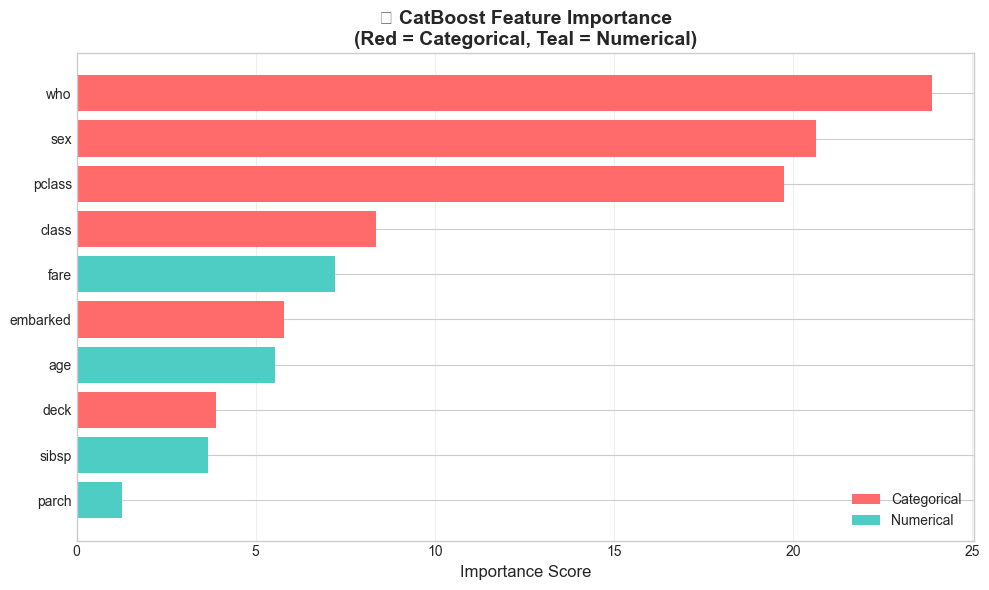

📊 Top 5 Most Important Features:
Feature  Importance
   fare    7.212862
  class    8.363678
 pclass   19.746806
    sex   20.633639
    who   23.870164


In [16]:
# Get feature importance
feature_importance = titanic_model_cb.get_feature_importance()
feature_names = X.columns

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B' if cat in cat_features else '#4ECDC4' for cat in importance_df['Feature']]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('🔍 CatBoost Feature Importance\n(Red = Categorical, Teal = Numerical)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label='Categorical'),
                   Patch(facecolor='#4ECDC4', label='Numerical')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('catboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Top 5 Most Important Features:")
print(importance_df.tail(5).to_string(index=False))


## 9. Training with Early Stopping and Pool Object

The `Pool` object is CatBoost's native data container that stores features, labels, and metadata efficiently. Combined with early stopping, it helps prevent overfitting and speeds up training.


In [17]:
# Create Pool objects for efficient training
train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_features_indices)

print("✅ Pool objects created!")
print(f"Train pool size: {train_pool.shape}")
print(f"Test pool size: {test_pool.shape}")

# Train with early stopping
model_early_stop = CatBoostClassifier(
    iterations=1000,  # Set high, will stop early
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features_indices,
    early_stopping_rounds=50,  # Stop if no improvement for 50 rounds
    verbose=100,
    random_seed=42,
    use_best_model=True  # Use the best iteration, not the last
)

print("\n🚀 Training with Early Stopping...")
model_early_stop.fit(
    train_pool,
    eval_set=test_pool,
    verbose=100
)

best_validation_metric = list(model_early_stop.get_best_score()['validation'].keys())[0]
best_validation_score = model_early_stop.get_best_score()['validation'][best_validation_metric]
print(f"\n✅ Training stopped at iteration: {model_early_stop.get_best_iteration()}")
print(f"Best validation {best_validation_metric}: {best_validation_score:.4f}")


✅ Pool objects created!
Train pool size: (712, 10)
Test pool size: (179, 10)

🚀 Training with Early Stopping...
0:	learn: 0.6369669	test: 0.6406369	best: 0.6406369 (0)	total: 42.7ms	remaining: 42.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4315563083
bestIteration = 20

Shrink model to first 21 iterations.

✅ Training stopped at iteration: 20
Best validation Logloss: 0.4316


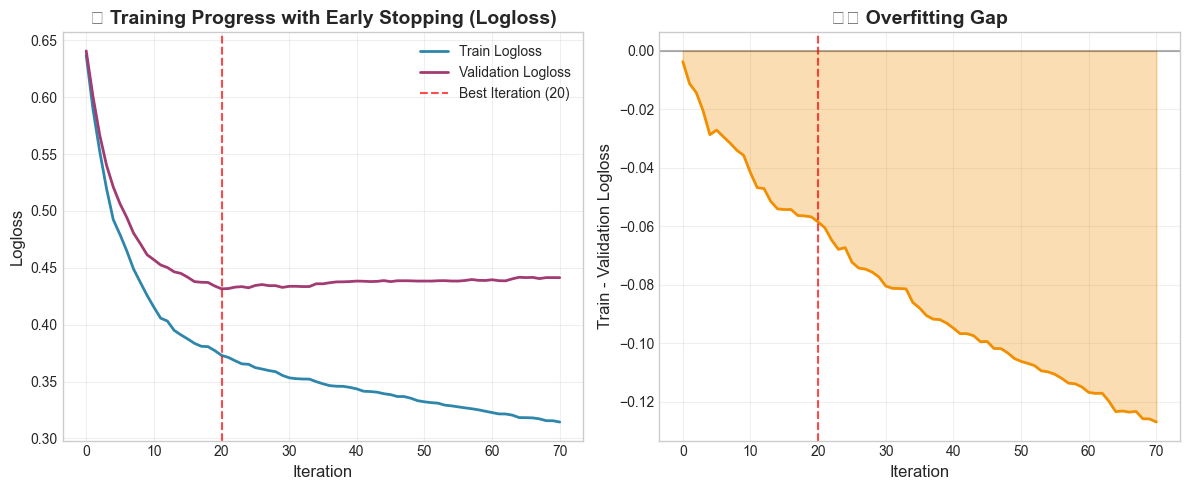


💡 Early stopping prevents overfitting by selecting the best model!


In [18]:
# Visualize training progress
evals_result = model_early_stop.get_evals_result()
metric_name = list(evals_result['learn'].keys())[0]
train_metric = evals_result['learn'][metric_name]
val_metric = evals_result['validation'][metric_name]
iterations = range(len(train_metric))

plt.figure(figsize=(12, 5))

# Plot 1: metric over iterations
plt.subplot(1, 2, 1)
plt.plot(iterations, train_metric, label=f'Train {metric_name}', linewidth=2, color='#2E86AB')
plt.plot(iterations, val_metric, label=f'Validation {metric_name}', linewidth=2, color='#A23B72')
best_iter = model_early_stop.get_best_iteration()
plt.axvline(x=best_iter, color='red', linestyle='--', alpha=0.7, label=f'Best Iteration ({best_iter})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(metric_name, fontsize=12)
plt.title(f'📊 Training Progress with Early Stopping ({metric_name})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Overfitting analysis (difference between train and val)
plt.subplot(1, 2, 2)
gap = np.array(train_metric) - np.array(val_metric)
plt.plot(iterations, gap, linewidth=2, color='#F18F01')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.fill_between(iterations, gap, alpha=0.3, color='#F18F01')
plt.axvline(x=best_iter, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(f'Train - Validation {metric_name}', fontsize=12)
plt.title('⚠️ Overfitting Gap', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('catboost_early_stopping.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Early stopping prevents overfitting by selecting the best model!")


## 10. Comparison: CatBoost vs XGBoost vs LightGBM

Let's compare the three major gradient boosting libraries on the same dataset :


In [19]:
# Compare CatBoost with XGBoost and LightGBM
# Note: XGBoost and LightGBM require preprocessing of categorical features

from sklearn.preprocessing import LabelEncoder
import time

# Preprocess for XGBoost and LightGBM (they need numerical input)
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

label_encoders = {}
for col in X_train.columns[cat_features_indices]:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    X_test_processed[col] = le.transform(X_test_processed[col].astype(str))
    label_encoders[col] = le

print("✅ Preprocessing complete for XGBoost and LightGBM")
print("(Label encoding applied to categorical features)")


✅ Preprocessing complete for XGBoost and LightGBM
(Label encoding applied to categorical features)


In [20]:
# Import XGBoost and LightGBM
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM not installed. Install with: pip install lightgbm")

# Comparison results
comparison_results = []

# 1. CatBoost (with native categorical handling)
print("\n🐱 Training CatBoost...")
start_time = time.time()
cb_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features_indices,
    verbose=False,
    random_seed=42
)
cb_model.fit(X_train, y_train)
cb_time = time.time() - start_time
cb_pred = cb_model.predict_proba(X_test)[:, 1]
cb_auc = roc_auc_score(y_test, cb_pred)
cb_acc = accuracy_score(y_test, cb_model.predict(X_test))

comparison_results.append({
    'Model': 'CatBoost',
    'AUC': cb_auc,
    'Accuracy': cb_acc,
    'Time (s)': cb_time,
    'Preprocessing': 'None (Native)'
})

print(f"✅ CatBoost: AUC={cb_auc:.4f}, Time={cb_time:.2f}s")



🐱 Training CatBoost...
✅ CatBoost: AUC=0.8520, Time=9.28s


In [21]:
# 2. XGBoost
if XGBOOST_AVAILABLE:
    print("\n⚡ Training XGBoost...")
    start_time = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train_processed, y_train)
    xgb_time = time.time() - start_time
    xgb_pred = xgb_model.predict_proba(X_test_processed)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_pred)
    xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test_processed))
    
    comparison_results.append({
        'Model': 'XGBoost',
        'AUC': xgb_auc,
        'Accuracy': xgb_acc,
        'Time (s)': xgb_time,
        'Preprocessing': 'Label Encoding Required'
    })
    print(f"✅ XGBoost: AUC={xgb_auc:.4f}, Time={xgb_time:.2f}s")



⚡ Training XGBoost...
✅ XGBoost: AUC=0.8164, Time=0.38s


In [22]:
# 3. LightGBM
if LIGHTGBM_AVAILABLE:
    print("\n🌿 Training LightGBM...")
    start_time = time.time()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train_processed, y_train)
    lgb_time = time.time() - start_time
    lgb_pred = lgb_model.predict_proba(X_test_processed)[:, 1]
    lgb_auc = roc_auc_score(y_test, lgb_pred)
    lgb_acc = accuracy_score(y_test, lgb_model.predict(X_test_processed))
    
    comparison_results.append({
        'Model': 'LightGBM',
        'AUC': lgb_auc,
        'Accuracy': lgb_acc,
        'Time (s)': lgb_time,
        'Preprocessing': 'Label Encoding Required'
    })
    print(f"✅ LightGBM: AUC={lgb_auc:.4f}, Time={lgb_time:.2f}s")



🌿 Training LightGBM...
✅ LightGBM: AUC=0.8176, Time=3.62s


In [23]:
# Display comparison results
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*60)
print("📊 BOOSTING LIBRARY COMPARISON RESULTS")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)



📊 BOOSTING LIBRARY COMPARISON RESULTS
   Model      AUC  Accuracy  Time (s)           Preprocessing
CatBoost 0.851976  0.815642  9.277026           None (Native)
 XGBoost 0.816403  0.798883  0.379074 Label Encoding Required
LightGBM 0.817589  0.787709  3.621085 Label Encoding Required


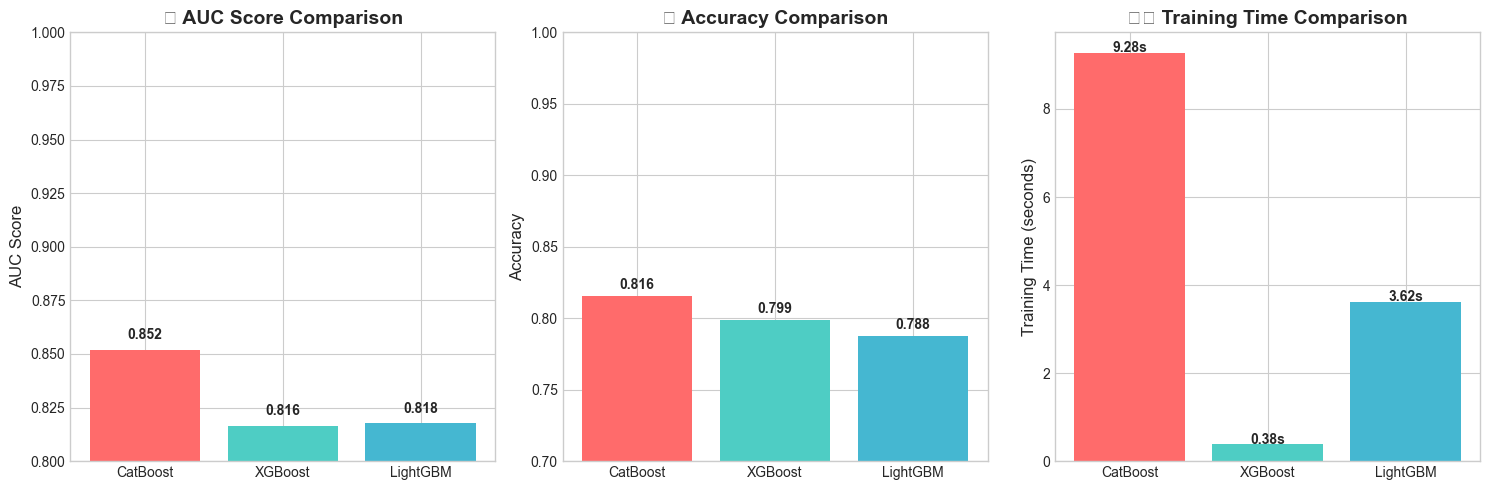


💡 Key Takeaways:
- CatBoost requires NO preprocessing for categorical features
- All three libraries achieve competitive performance
- CatBoost often has fastest inference due to symmetric trees


In [24]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = comparison_df['Model']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(models)]

# AUC Comparison
axes[0].bar(models, comparison_df['AUC'], color=colors)
axes[0].set_ylabel('AUC Score', fontsize=12)
axes[0].set_title('🎯 AUC Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.8, 1.0)
for i, v in enumerate(comparison_df['AUC']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Accuracy Comparison
axes[1].bar(models, comparison_df['Accuracy'], color=colors)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('✅ Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.7, 1.0)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Training Time Comparison
axes[2].bar(models, comparison_df['Time (s)'], color=colors)
axes[2].set_ylabel('Training Time (seconds)', fontsize=12)
axes[2].set_title('⏱️ Training Time Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(comparison_df['Time (s)']):
    axes[2].text(i, v + 0.01, f'{v:.2f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('boosting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Key Takeaways:")
print("- CatBoost requires NO preprocessing for categorical features")
print("- All three libraries achieve competitive performance")
print("- CatBoost often has fastest inference due to symmetric trees")


## 11. Best Practices and When to Choose CatBoost

### ✅ When to Choose CatBoost

1. **Datasets with Categorical Features**: CatBoost's native categorical handling saves preprocessing time and often improves accuracy
2. **Minimal Tuning Required**: Default parameters are highly competitive
3. **Fast Inference Needed**: Symmetric trees enable fastest prediction speeds
4. **Small to Medium Datasets**: Ordered boosting provides strong overfitting resistance
5. **Production Systems**: Excellent model export options (ONNX, CoreML, etc.)

### ⚠️ When to Consider Alternatives

1. **Purely Numeric Large Datasets**: LightGBM may train faster
2. **Maximum Training Speed Priority**: LightGBM is generally fastest
3. **Fine-grained Control Needed**: XGBoost offers more tuning knobs

### 🎯 Best Practices

1. **Specify Categorical Features**: Always use `cat_features` parameter
2. **Use Pool Objects**: For large datasets, Pool objects improve efficiency
3. **Enable Early Stopping**: Prevents overfitting and reduces training time
4. **Start with Defaults**: CatBoost defaults are well-tuned
5. **Consider GPU**: Use `task_type='GPU'` for large datasets
6. **Handle Missing Values**: Let CatBoost handle them natively

### 📊 Summary Comparison Table

| Feature | CatBoost | XGBoost | LightGBM |
|---------|----------|---------|----------|
| Categorical Handling | ✅ Native | ❌ Manual | ⚠️ Limited |
| Default Performance | ⭐⭐⭐ Excellent | ⭐⭐ Good | ⭐⭐ Good |
| Training Speed | ⭐⭐ Moderate | ⭐⭐⭐ Fast | ⭐⭐⭐⭐ Fastest |
| Inference Speed | ⭐⭐⭐⭐ Fastest | ⭐⭐⭐ Fast | ⭐⭐⭐ Fast |
| Overfitting Resistance | ⭐⭐⭐⭐ Strong | ⭐⭐⭐ Good | ⭐⭐ Moderate |
| Ease of Use | ⭐⭐⭐⭐ Easy | ⭐⭐⭐ Moderate | ⭐⭐⭐ Moderate |

Based on research comparing these libraries across multiple datasets .


## 🛠️ Hands-On Exercises

Test your understanding with these practical exercises!

### Exercise 1: Basic CatBoost Model
Train a basic CatBoost classifier on a dataset with at least 3 categorical features. Don't do any encoding - let CatBoost handle it!


In [25]:
# Exercise 1: Your code here



### Exercise 2: Using CatBoost Pool
Create a CatBoost Pool object and use it for training. Compare the training time with and without Pool.


In [26]:
# Exercise 2: Your code here



### Exercise 3: Hyperparameter Tuning
Experiment with different combinations of `iterations`, `learning_rate`, and `depth`. Plot how accuracy changes with different settings.


In [27]:
# Exercise 3: Your code here



### Exercise 4: Compare with XGBoost
Load a dataset, preprocess categorical features for XGBoost (label encoding), and compare performance with CatBoost (no preprocessing).


In [28]:
# Exercise 4: Your code here



### Exercise 5: Analyze Categorical Handling
Create a dataset with high-cardinality categorical features (e.g., 100+ unique values). Compare CatBoost's performance vs one-hot encoding approach.


In [29]:
# Exercise 5: Your code here



### Exercise 6: Early Stopping
Train a model with early stopping on a validation set. Visualize the training curve and identify the optimal stopping point.


In [30]:
# Exercise 6: Your code here



### Exercise 7: Feature Importance Analysis
Train a CatBoost model and extract SHAP values for interpretability. Identify the top 3 most important features.


In [31]:
# Exercise 7: Your code here



### Exercise 8: Regression with CatBoostRegressor
Use `CatBoostRegressor` on a regression dataset (e.g., predict house prices). Handle categorical features like 'neighborhood' or 'house_type'.


In [32]:
# Exercise 8: Your code here



### Exercise 9: Complete Pipeline
Build a complete ML pipeline: load data → minimal preprocessing → CatBoost training → evaluation → feature importance visualization.


In [33]:
# Exercise 9: Your code here



### Exercise 10: Cross-Validation
Implement cross-validation with CatBoost and compare results with a single train-test split.


In [34]:
# Exercise 10: Your code here



## Solutions (Review After Attempting)

Below are detailed solutions with best practices. Review these after attempting the exercises yourself!


### Solution 1: Basic CatBoost Model


In [35]:
# Solution 1: Basic CatBoost Model
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create sample data with categorical features
np.random.seed(42)
data = {
    'color': np.random.choice(['Red', 'Blue', 'Green', 'Yellow'], 500),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 500),
    'material': np.random.choice(['Wood', 'Metal', 'Plastic', 'Glass'], 500),
    'price': np.random.randint(10, 1000, 500),
    'weight': np.random.randint(1, 100, 500)
}
df = pd.DataFrame(data)

# Create target based on rules
df['target'] = (
    (df['color'] == 'Red').astype(int) * 0.4 +
    (df['size'] == 'Large').astype(int) * 0.3 +
    (df['material'] == 'Metal').astype(int) * 0.2 +
    (df['price'] > 500).astype(int) * 0.1 +
    np.random.normal(0, 0.1, 500)
).round().astype(int)

# Split data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical features
cat_features = ['color', 'size', 'material']
cat_indices = [X.columns.get_loc(col) for col in cat_features]

# Train CatBoost - NO preprocessing needed!
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_indices,
    verbose=False,
    random_seed=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"✅ Solution 1 Complete!")
print(f"Accuracy: {accuracy:.4f}")
print(f"Categorical features handled natively: {cat_features}")


✅ Solution 1 Complete!
Accuracy: 0.8400
Categorical features handled natively: ['color', 'size', 'material']


### Solution 2: Using CatBoost Pool


In [36]:
# Solution 2: Using CatBoost Pool
import time
from catboost import Pool

# Without Pool
start = time.time()
model1 = CatBoostClassifier(iterations=200, verbose=False, random_seed=42)
model1.fit(X_train, y_train, cat_features=cat_indices)
time_without_pool = time.time() - start

# With Pool
start = time.time()
train_pool = Pool(X_train, y_train, cat_features=cat_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_indices)
model2 = CatBoostClassifier(iterations=200, verbose=False, random_seed=42)
model2.fit(train_pool)
time_with_pool = time.time() - start

print(f"✅ Solution 2 Complete!")
print(f"Time without Pool: {time_without_pool:.4f}s")
print(f"Time with Pool: {time_with_pool:.4f}s")
print(f"Pool efficiency gain: {(1 - time_with_pool/time_without_pool)*100:.1f}%")
print(f"\n💡 Pool objects are especially beneficial for large datasets!")


✅ Solution 2 Complete!
Time without Pool: 7.4421s
Time with Pool: 7.4970s
Pool efficiency gain: -0.7%

💡 Pool objects are especially beneficial for large datasets!


### Solution 3: Hyperparameter Tuning


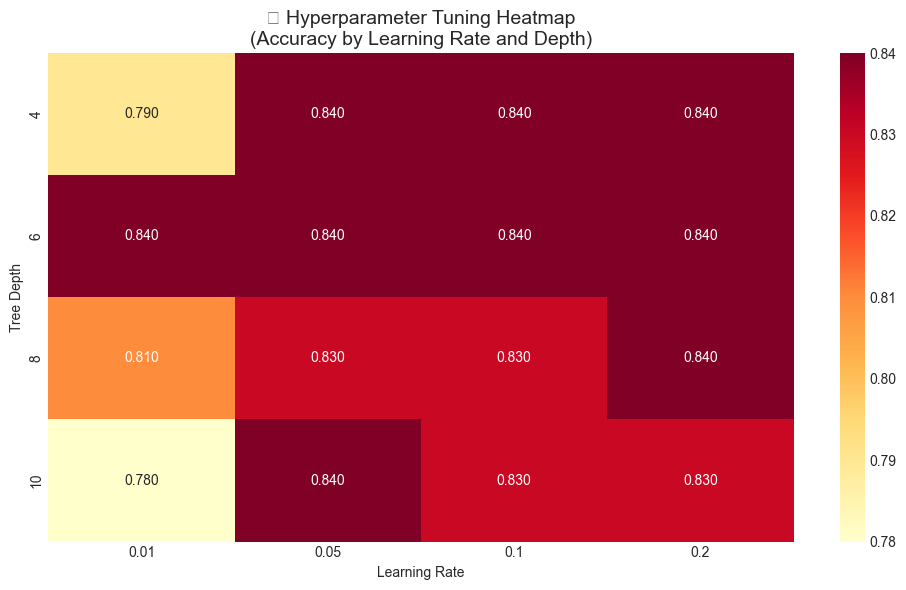

✅ Solution 3 Complete!
Best parameters: lr=0.01, depth=6
Best accuracy: 0.8400


In [37]:
# Solution 3: Hyperparameter Tuning
import matplotlib.pyplot as plt

# Grid of hyperparameters
learning_rates = [0.01, 0.05, 0.1, 0.2]
depths = [4, 6, 8, 10]

results = []
for lr in learning_rates:
    for depth in depths:
        model = CatBoostClassifier(
            iterations=100,
            learning_rate=lr,
            depth=depth,
            cat_features=cat_indices,
            verbose=False,
            random_seed=42
        )
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append({'lr': lr, 'depth': depth, 'accuracy': acc})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='depth', columns='lr', values='accuracy')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('🔍 Hyperparameter Tuning Heatmap\n(Accuracy by Learning Rate and Depth)', fontsize=14)
plt.xlabel('Learning Rate')
plt.ylabel('Tree Depth')
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['accuracy'].idxmax()]
print(f"✅ Solution 3 Complete!")
print(f"Best parameters: lr={best['lr']}, depth={int(best['depth'])}")
print(f"Best accuracy: {best['accuracy']:.4f}")


### Solution 4: Compare with XGBoost


In [38]:
# Solution 4: Compare with XGBoost
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Prepare data for XGBoost (requires encoding)
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

encoders = {}
for col in cat_features:
    le = LabelEncoder()
    X_train_xgb[col] = le.fit_transform(X_train_xgb[col])
    X_test_xgb[col] = le.transform(X_test_xgb[col])
    encoders[col] = le

# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_xgb, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test_xgb))

# Train CatBoost (no encoding)
cb_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, 
                               cat_features=cat_indices, verbose=False, random_seed=42)
cb_model.fit(X_train, y_train)
cb_acc = accuracy_score(y_test, cb_model.predict(X_test))

print(f"✅ Solution 4 Complete!")
print(f"XGBoost accuracy: {xgb_acc:.4f} (with label encoding)")
print(f"CatBoost accuracy: {cb_acc:.4f} (no preprocessing)")
print(f"Winner: {'CatBoost' if cb_acc > xgb_acc else 'XGBoost' if xgb_acc > cb_acc else 'Tie'}")


✅ Solution 4 Complete!
XGBoost accuracy: 0.8600 (with label encoding)
CatBoost accuracy: 0.8400 (no preprocessing)
Winner: XGBoost


### Solution 5: High-Cardinality Categorical Features


In [39]:
# Solution 5: High-Cardinality Features
np.random.seed(42)
n_samples = 1000

# Create high-cardinality feature (200 unique values)
cities = [f'City_{i}' for i in range(200)]
data = {
    'city': np.random.choice(cities, n_samples),
    'income': np.random.randint(20000, 150000, n_samples),
    'age': np.random.randint(18, 80, n_samples)
}
df = pd.DataFrame(data)

# Target depends on city (some cities have higher targets)
city_effect = {city: np.random.random() for city in cities}
df['target'] = (
    df['city'].map(city_effect) * 0.5 +
    (df['income'] > 80000).astype(int) * 0.3 +
    (df['age'] > 50).astype(int) * 0.2
).round().astype(int)

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CatBoost approach (native handling)
cat_idx = [0]  # city column
cb_model = CatBoostClassifier(iterations=100, verbose=False, random_seed=42)
cb_model.fit(X_train, y_train, cat_features=cat_idx)
cb_acc = accuracy_score(y_test, cb_model.predict(X_test))

# One-hot approach (for comparison)
X_train_ohe = pd.get_dummies(X_train, columns=['city'])
X_test_ohe = pd.get_dummies(X_test, columns=['city'])

# Align columns
train_cols = set(X_train_ohe.columns)
test_cols = set(X_test_ohe.columns)
missing_in_test = train_cols - test_cols
for col in missing_in_test:
    X_test_ohe[col] = 0
X_test_ohe = X_test_ohe[X_train_ohe.columns]

from sklearn.ensemble import GradientBoostingClassifier
ohe_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
ohe_model.fit(X_train_ohe, y_train)
ohe_acc = accuracy_score(y_test, ohe_model.predict(X_test_ohe))

print(f"✅ Solution 5 Complete!")
print(f"CatBoost (native): {cb_acc:.4f}")
print(f"One-Hot + GBM: {ohe_acc:.4f}")
print(f"Memory: CatBoost uses ~{X_train.memory_usage(deep=True).sum()/1024:.1f}KB vs One-Hot ~{X_train_ohe.memory_usage(deep=True).sum()/1024:.1f}KB")


✅ Solution 5 Complete!
CatBoost (native): 0.8650
One-Hot + GBM: 0.8500
Memory: CatBoost uses ~24.7KB vs One-Hot ~165.6KB


### Solution 6: Early Stopping


0:	learn: 0.5861419	test: 0.5946565	best: 0.5946565 (0)	total: 28.3ms	remaining: 14.1s
50:	learn: 0.2016069	test: 0.2323810	best: 0.2314289 (49)	total: 1.86s	remaining: 16.3s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.2124437332
bestIteration = 77

Shrink model to first 78 iterations.


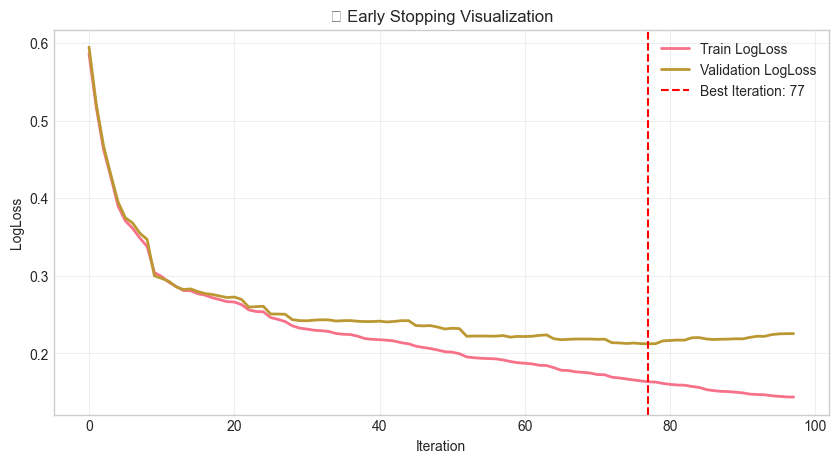

✅ Solution 6 Complete!
Training stopped at iteration: 77
Total iterations requested: 500
Early stopping saved: 423 iterations


In [40]:
# Solution 6: Early Stopping
from catboost import Pool

# Create pools
train_pool = Pool(X_train, y_train, cat_features=cat_idx)
val_pool = Pool(X_test, y_test, cat_features=cat_idx)

# Train with early stopping
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    early_stopping_rounds=20,
    use_best_model=True,
    verbose=False,
    random_seed=42
)

model.fit(train_pool, eval_set=val_pool, verbose=50)

# Get evaluation results
evals = model.get_evals_result()
train_logloss = evals['learn']['Logloss']
val_logloss = evals['validation']['Logloss']

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_logloss, label='Train LogLoss', linewidth=2)
plt.plot(val_logloss, label='Validation LogLoss', linewidth=2)
plt.axvline(x=model.get_best_iteration(), color='red', linestyle='--', 
            label=f'Best Iteration: {model.get_best_iteration()}')
plt.xlabel('Iteration')
plt.ylabel('LogLoss')
plt.title('📉 Early Stopping Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"✅ Solution 6 Complete!")
print(f"Training stopped at iteration: {model.get_best_iteration()}")
print(f"Total iterations requested: 500")
print(f"Early stopping saved: {500 - model.get_best_iteration()} iterations")


### Solution 7: SHAP Values


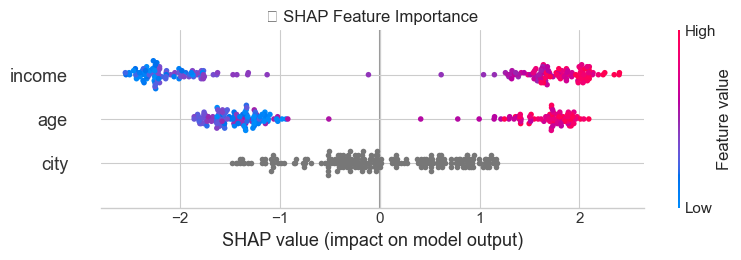

✅ Solution 7 Complete!
Top 3 most important features:
  1. income: 46.90
  2. age: 36.01
  3. city: 17.10


In [41]:
# Solution 7: SHAP Values
# Note: This requires shap package: pip install shap

try:
    import shap
    
    # Train model
    model = CatBoostClassifier(iterations=100, verbose=False, random_seed=42)
    model.fit(X_train, y_train, cat_features=cat_idx)
    
    # Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title('🔍 SHAP Feature Importance')
    plt.tight_layout()
    plt.show()
    
    # Get feature importance
    importance = model.get_feature_importance()
    feature_names = X_train.columns
    top3_idx = np.argsort(importance)[-3:][::-1]
    
    print(f"✅ Solution 7 Complete!")
    print(f"Top 3 most important features:")
    for i, idx in enumerate(top3_idx, 1):
        print(f"  {i}. {feature_names[idx]}: {importance[idx]:.2f}")
        
except ImportError:
    print("⚠️ Install shap package for this solution: pip install shap")
    print("Alternative: Using built-in feature importance")
    
    model = CatBoostClassifier(iterations=100, verbose=False, random_seed=42)
    model.fit(X_train, y_train, cat_features=cat_idx)
    importance = model.get_feature_importance()
    feature_names = X_train.columns
    top3_idx = np.argsort(importance)[-3:][::-1]
    
    print(f"✅ Solution 7 (Alternative) Complete!")
    print(f"Top 3 most important features:")
    for i, idx in enumerate(top3_idx, 1):
        print(f"  {i}. {feature_names[idx]}: {importance[idx]:.2f}")


### Solution 8: Regression with CatBoostRegressor


In [42]:
# Solution 8: CatBoostRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create synthetic house price data
np.random.seed(42)
n = 1000
house_data = {
    'neighborhood': np.random.choice(['Downtown', 'Suburbs', 'Rural', 'Beachfront', 'Industrial'], n),
    'house_type': np.random.choice(['Apartment', 'House', 'Condo', 'Townhouse'], n),
    'bedrooms': np.random.randint(1, 6, n),
    'bathrooms': np.random.randint(1, 4, n),
    'sqft': np.random.randint(500, 5000, n),
    'year_built': np.random.randint(1950, 2023, n),
    'has_pool': np.random.choice(['Yes', 'No'], n)
}
df = pd.DataFrame(house_data)

# Create price target
base_price = 50000
df['price'] = (
    base_price +
    df['sqft'] * 150 +
    df['bedrooms'] * 25000 +
    df['bathrooms'] * 15000 +
    (df['neighborhood'] == 'Beachfront').astype(int) * 200000 +
    (df['neighborhood'] == 'Downtown').astype(int) * 100000 +
    (df['house_type'] == 'House').astype(int) * 50000 +
    (2023 - df['year_built']) * -1000 +
    np.random.normal(0, 50000, n)
)

X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features_reg = ['neighborhood', 'house_type', 'has_pool']
cat_indices_reg = [X.columns.get_loc(col) for col in cat_features_reg]

# Train regressor
regressor = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_indices_reg,
    verbose=False,
    random_seed=42
)

regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"✅ Solution 8 Complete!")
print(f"RMSE: ${np.sqrt(mse):,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Categorical features handled: {cat_features_reg}")


✅ Solution 8 Complete!
RMSE: $57,670.83
R² Score: 0.9306
Categorical features handled: ['neighborhood', 'house_type', 'has_pool']


### Solution 9: Complete Pipeline


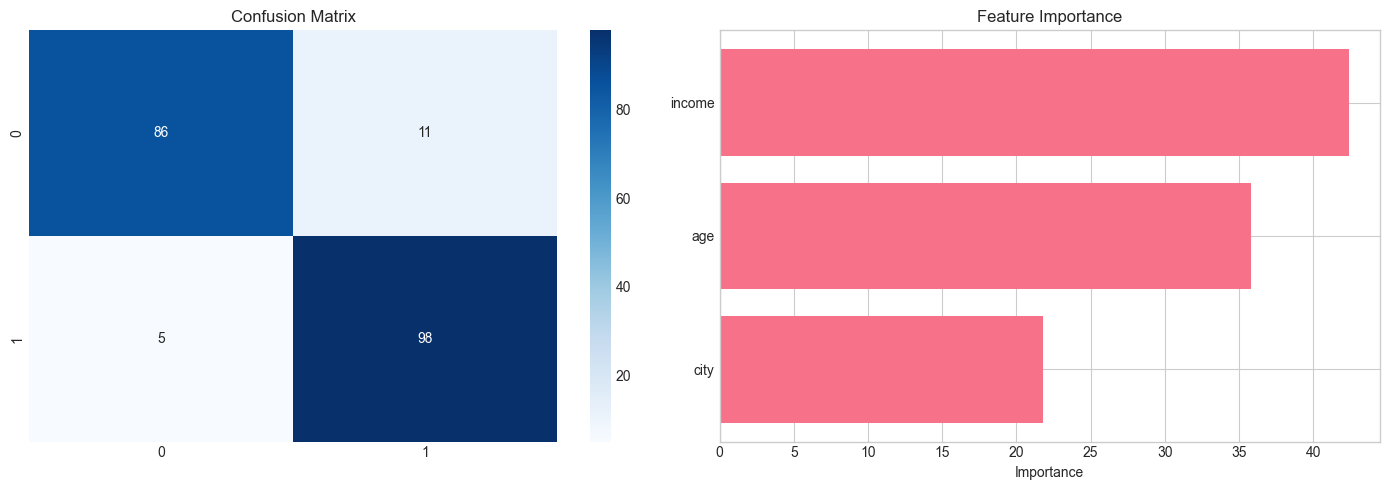

✅ Solution 9 Complete!
Pipeline accuracy: 0.9200

Top 5 features:
feature  importance
 income   42.377469
    age   35.836193
   city   21.786338


In [43]:
# Solution 9: Complete Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Ensure we have the classification dataset
np.random.seed(42)
cities = [f'City_{i}' for i in range(200)]
data = {
    'city': np.random.choice(cities, 1000),
    'income': np.random.randint(20000, 150000, 1000),
    'age': np.random.randint(18, 80, 1000)
}
df = pd.DataFrame(data)
city_effect = {city: np.random.random() for city in cities}
df['target'] = (
    df['city'].map(city_effect) * 0.5 +
    (df['income'] > 80000).astype(int) * 0.3 +
    (df['age'] > 50).astype(int) * 0.2
).round().astype(int)


def catboost_pipeline(df, target_col, cat_features=None, test_size=0.2):
    """
    Complete CatBoost pipeline with minimal preprocessing
    """
    # 1. Separate features and target
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # 2. Auto-detect categorical features if not specified
    if cat_features is None:
        cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    cat_indices = [X.columns.get_loc(col) for col in cat_features]
    
    # 3. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # 4. Train CatBoost
    model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        cat_features=cat_indices,
        verbose=False,
        random_seed=42
    )
    
    model.fit(X_train, y_train)
    
    # 5. Evaluate
    predictions = model.predict(X_test)
    report = classification_report(y_test, predictions, output_dict=True)
    
    # 6. Feature importance
    importance = model.get_feature_importance()
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # 7. Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    
    # Feature importance
    axes[1].barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
    axes[1].set_title('Feature Importance')
    axes[1].set_xlabel('Importance')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model,
        'accuracy': report['accuracy'],
        'feature_importance': importance_df,
        'predictions': predictions
    }

# Run pipeline on our dataset
result = catboost_pipeline(df, 'target', cat_features=['city'])
print(f"✅ Solution 9 Complete!")
print(f"Pipeline accuracy: {result['accuracy']:.4f}")
print(f"\nTop 5 features:")
print(result['feature_importance'].head().to_string(index=False))


### Solution 10: Cross-Validation


In [44]:
# Solution 10: Cross-Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
# Ensure we have the classification dataset
np.random.seed(42)
cities = [f'City_{i}' for i in range(200)]
data = {
    'city': np.random.choice(cities, 1000),
    'income': np.random.randint(20000, 150000, 1000),
    'age': np.random.randint(18, 80, 1000)
}
df = pd.DataFrame(data)
city_effect = {city: np.random.random() for city in cities}
df['target'] = (
    df['city'].map(city_effect) * 0.5 +
    (df['income'] > 80000).astype(int) * 0.3 +
    (df['age'] > 50).astype(int) * 0.2
).round().astype(int)


# Prepare data
X = df.drop('target', axis=1)
y = df['target']
cat_idx = [0]  # city column

# CatBoost with cross-validation
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_idx,
    verbose=False,
    random_seed=42
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

# Single train-test split for comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
single_score = accuracy_score(y_test, model.predict(X_test))

# Results
print(f"✅ Solution 10 Complete!")
print(f"\n5-Fold Cross-Validation:")
print(f"  Scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"\nSingle Train-Test Split:")
print(f"  Score: {single_score:.4f}")
print(f"\n💡 Cross-validation gives a more robust estimate of model performance!")


✅ Solution 10 Complete!

5-Fold Cross-Validation:
  Scores: [0.88  0.855 0.925 0.905 0.88 ]
  Mean: 0.8890 (+/- 0.0479)

Single Train-Test Split:
  Score: 0.8650

💡 Cross-validation gives a more robust estimate of model performance!
